In [5]:
import os

print("Kaggle input folders:")
print(os.listdir("/kaggle/input"))

Kaggle input folders:
['datasets']


In [6]:
import os

INPUT_ROOT = "/kaggle/input"

matches = []

for root, dirs, files in os.walk(INPUT_ROOT):
    for d in dirs:
        if d.upper() == "FINALCNNDATA_FINAL":
            matches.append(os.path.join(root, d))

print("Dataset folders found:")

for path in matches:
    print(path)

Dataset folders found:
/kaggle/input/datasets/beginne/datasetcnn/FINALCNNDATA_FINAL


In [7]:
import os

if len(matches) == 0:
    raise FileNotFoundError(
        "FINALCNNDATA_FINAL was not found inside /kaggle/input."
    )

DATA_ROOT = matches[0]

print("DATA_ROOT:")
print(DATA_ROOT)

DATA_ROOT:
/kaggle/input/datasets/beginne/datasetcnn/FINALCNNDATA_FINAL


In [9]:
# ============================================================
# CELL 5 — IMPORTS + DEVICE
# ============================================================

import os
import glob
import numpy as np
import rasterio

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [10]:
# ============================================================
# CELL 6 — PATCH DATASET
# ============================================================

class PatchDataset(Dataset):

    def __init__(self, filepaths, labels):
        self.filepaths = filepaths
        self.labels = labels

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):

        filepath = self.filepaths[idx]
        label = self.labels[idx]

        # ----------------------------------------------------
        # Read 11-channel GeoTIFF
        # ----------------------------------------------------
        with rasterio.open(filepath) as src:
            image = src.read()

        # Convert to float32
        image = image.astype(np.float32)

        # ----------------------------------------------------
        # Safety check
        # Expected shape:
        # (11, H, W)
        # ----------------------------------------------------
        if image.ndim != 3:
            raise ValueError(
                f"Unexpected image shape {image.shape} "
                f"for file:\n{filepath}"
            )

        if image.shape[0] != 11:
            raise ValueError(
                f"Expected 11 channels but found "
                f"{image.shape[0]} channels in:\n{filepath}"
            )

        # ----------------------------------------------------
        # Replace NaN / Inf values
        # ----------------------------------------------------
        image = np.nan_to_num(
            image,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        # ----------------------------------------------------
        # Per-channel normalization
        # ----------------------------------------------------
        for c in range(image.shape[0]):

            channel = image[c]

            mean = channel.mean()
            std = channel.std()

            if std > 1e-6:
                image[c] = (channel - mean) / std
            else:
                image[c] = channel - mean

        # ----------------------------------------------------
        # Convert NumPy → PyTorch tensor
        # ----------------------------------------------------
        image = torch.from_numpy(image).float()

        label = torch.tensor(
            label,
            dtype=torch.float32
        )

        return image, label


print("PatchDataset class is ready.")

PatchDataset class is ready.


In [11]:
# ============================================================
# CELL 7 — COLLECT FILE PATHS AND LABELS
# ============================================================

def collect_split(split_name):

    split_dir = os.path.join(
        DATA_ROOT,
        split_name
    )

    site_dir = os.path.join(
        split_dir,
        "site"
    )

    no_site_dir = os.path.join(
        split_dir,
        "no_site"
    )

    if not os.path.exists(site_dir):
        raise FileNotFoundError(
            f"Site folder not found:\n{site_dir}"
        )

    if not os.path.exists(no_site_dir):
        raise FileNotFoundError(
            f"No-site folder not found:\n{no_site_dir}"
        )

    # --------------------------------------------------------
    # Find TIFF files
    # --------------------------------------------------------
    site_files = sorted(
        glob.glob(
            os.path.join(site_dir, "*.tif")
        )
    )

    no_site_files = sorted(
        glob.glob(
            os.path.join(no_site_dir, "*.tif")
        )
    )

    # --------------------------------------------------------
    # Labels
    # site    = 1
    # no_site = 0
    # --------------------------------------------------------
    filepaths = (
        site_files +
        no_site_files
    )

    labels = (
        [1] * len(site_files) +
        [0] * len(no_site_files)
    )

    return filepaths, labels


train_fp, train_lb = collect_split("train")

val_fp, val_lb = collect_split("validation")

test_fp, test_lb = collect_split("test")


print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(
    f"Train:      {len(train_fp)} "
    f"(site={sum(train_lb)}, no_site={len(train_lb)-sum(train_lb)})"
)

print(
    f"Validation: {len(val_fp)} "
    f"(site={sum(val_lb)}, no_site={len(val_lb)-sum(val_lb)})"
)

print(
    f"Test:       {len(test_fp)} "
    f"(site={sum(test_lb)}, no_site={len(test_lb)-sum(test_lb)})"
)

print("=" * 60)

DATASET SUMMARY
Train:      2549 (site=812, no_site=1737)
Validation: 523 (site=111, no_site=412)
Test:       545 (site=173, no_site=372)


In [12]:
# ============================================================
# CELL 8 — DATASETS AND DATALOADERS
# ============================================================

BATCH_SIZE = 16

train_dataset = PatchDataset(
    train_fp,
    train_lb
)

val_dataset = PatchDataset(
    val_fp,
    val_lb
)

test_dataset = PatchDataset(
    test_fp,
    test_lb
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("=" * 60)
print("DATALOADERS READY")
print("=" * 60)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DATALOADERS READY
Train samples: 2549
Validation samples: 523
Test samples: 545
Train batches: 160
Validation batches: 33
Test batches: 35


In [14]:
# ============================================================
# CELL 10 — CNN ARCHITECTURE
# ============================================================

class CNNBaseline(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------------
        # CONVOLUTIONAL BLOCK 1
        # 11 channels → 16 filters
        # ----------------------------------------------------
        self.block1 = nn.Sequential(

            nn.Conv2d(
                in_channels=11,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # ----------------------------------------------------
        # CONVOLUTIONAL BLOCK 2
        # 16 → 32 filters
        # ----------------------------------------------------
        self.block2 = nn.Sequential(

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # ----------------------------------------------------
        # CONVOLUTIONAL BLOCK 3
        # 32 → 64 filters
        # ----------------------------------------------------
        self.block3 = nn.Sequential(

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(inplace=True),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        # ----------------------------------------------------
        # ADAPTIVE GLOBAL AVERAGE POOLING
        # ----------------------------------------------------
        self.global_pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------
        self.dropout = nn.Dropout(
            p=0.4
        )

        self.fc = nn.Linear(
            64,
            1
        )

    def forward(self, x):

        x = self.block1(x)

        x = self.block2(x)

        x = self.block3(x)

        x = self.global_pool(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        x = self.dropout(x)

        x = self.fc(x)

        return x.squeeze(1)


print("CNNBaseline class is ready.")

CNNBaseline class is ready.


In [15]:
# ============================================================
# CELL 11 — CREATE MODEL
# ============================================================

model = CNNBaseline().to(DEVICE)

print(model)

CNNBaseline(
  (block1): Sequential(
    (0): Conv2d(11, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (global_pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (dropout): Dropout

In [17]:
# ============================================================
# CELL 13 — LOSS FUNCTION, OPTIMIZER AND SCHEDULER
# ============================================================

# ------------------------------------------------------------
# COMPUTE CLASS WEIGHT FROM TRAINING DATA
# ------------------------------------------------------------

train_labels = np.array(train_lb)

num_negative = np.sum(train_labels == 0)
num_positive = np.sum(train_labels == 1)

print("Training samples:")
print("Negative (no_site):", num_negative)
print("Positive (site):   ", num_positive)

# Give more importance to the minority class
pos_weight = num_negative / max(num_positive, 1)

print("Positive class weight:", pos_weight)


# ------------------------------------------------------------
# LOSS FUNCTION
# ------------------------------------------------------------

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(
        pos_weight,
        dtype=torch.float32,
        device=DEVICE
    )
)


# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# LEARNING RATE SCHEDULER
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("\nLoss, optimizer and scheduler are ready.")
print("Initial learning rate:", optimizer.param_groups[0]["lr"])

Training samples:
Negative (no_site): 1737
Positive (site):    812
Positive class weight: 2.1391625615763545

Loss, optimizer and scheduler are ready.
Initial learning rate: 0.0003


In [18]:
# ============================================================
# CELL 14 — TRAINING / VALIDATION FUNCTION
# ============================================================

from sklearn.metrics import f1_score, roc_auc_score
from tqdm.auto import tqdm


def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
    scaler=None,
    train=False
):

    if train:
        model.train()
    else:
        model.eval()


    total_loss = 0.0

    all_probs = []
    all_labels = []


    # --------------------------------------------------------
    # LOOP THROUGH BATCHES
    # --------------------------------------------------------

    progress = tqdm(
        loader,
        desc="Train" if train else "Validation",
        leave=False
    )


    for images, labels in progress:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )


        if train:

            optimizer.zero_grad(
                set_to_none=True
            )


        # ----------------------------------------------------
        # FORWARD PASS
        # ----------------------------------------------------

        with torch.set_grad_enabled(train):

            with torch.amp.autocast(
                device_type="cuda",
                enabled=(DEVICE.type == "cuda")
            ):

                logits = model(images)

                loss = criterion(
                    logits,
                    labels
                )
            # ------------------------------------------------
            # BACKPROPAGATION
            # ------------------------------------------------

            if train:

                if scaler is not None:

                    scaler.scale(
                        loss
                    ).backward()

                    scaler.step(
                        optimizer
                    )

                    scaler.update()

                else:

                    loss.backward()
                    optimizer.step()

        # ----------------------------------------------------
        # STORE LOSS
        # ----------------------------------------------------

        total_loss += (
            loss.item()
            * images.size(0)
        )


        # ----------------------------------------------------
        # CONVERT LOGITS → PROBABILITIES
        # ----------------------------------------------------

        probs = torch.sigmoid(
            logits
        )


        all_probs.extend(
            probs.detach()
            .cpu()
            .numpy()
        )

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
        )


    # --------------------------------------------------------
    # AVERAGE LOSS
    # --------------------------------------------------------

    avg_loss = (
        total_loss /
        len(loader.dataset)
    )


    all_probs = np.array(
        all_probs
    )

    all_labels = np.array(
        all_labels
    )


    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    predictions = (
        all_probs >= 0.5
    ).astype(int)


    # --------------------------------------------------------
    # F1 SCORE
    # --------------------------------------------------------

    f1 = f1_score(
        all_labels,
        predictions,
        zero_division=0
    )
    # --------------------------------------------------------
    # ROC AUC
    # --------------------------------------------------------

    if len(
        np.unique(all_labels)
    ) == 2:

        auc = roc_auc_score(
            all_labels,
            all_probs
        )

    else:

        auc = float("nan")


    return (
        avg_loss,
        f1,
        auc,
        all_probs,
        all_labels
    )


print("run_epoch() is ready.")

run_epoch() is ready.


In [19]:
# ============================================================
# CELL 15 — MIXED PRECISION SCALER
# ============================================================

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(DEVICE.type == "cuda")
)

print("AMP scaler ready.")

AMP scaler ready.


In [28]:
# ============================================================
# CELL 16 — FINAL TRAINING
# ============================================================

# ------------------------------------------------------------
# TRAINING CONFIGURATION
# ------------------------------------------------------------

CONFIG = {

    # Number of maximum training epochs
    "epochs": 20,

    # Stop if validation AUC does not improve
    "early_stop_patience": 4,

    # Where to save the best model
    "checkpoint_path":
        "/kaggle/working/best_cnn_model.pth"
}


# ------------------------------------------------------------
# INITIALIZE TRAINING VARIABLES
# ------------------------------------------------------------

best_metric = -float("inf")

epochs_no_improve = 0


history = {

    "train_loss": [],
    "val_loss": [],

    "train_f1": [],
    "val_f1": [],

    "train_auc": [],
    "val_auc": []

}


print("\n======================================")
print("STARTING TRAINING")
print("======================================")

print(
    f"Maximum epochs: "
    f"{CONFIG['epochs']}"
)

print(
    f"Early stopping patience: "
    f"{CONFIG['early_stop_patience']}"
)

print(
    f"Checkpoint: "
    f"{CONFIG['checkpoint_path']}"
)


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(
    1,
    CONFIG["epochs"] + 1
):


    # ========================================================
    # TRAIN
    # ========================================================

    (
        train_loss,
        train_f1,
        train_auc,
        _,
        _
    ) = run_epoch(

        model,

        train_loader,

        criterion,

        optimizer,

        scaler,

        train=True
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    (
        val_loss,
        val_f1,
        val_auc,
        _,
        _
    ) = run_epoch(

        model,

        val_loader,

        criterion,

        train=False
    )


    # ========================================================
    # LEARNING RATE SCHEDULER
    # ========================================================

    scheduler.step(
        val_loss
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history[
        "train_loss"
    ].append(
        train_loss
    )

    history[
        "val_loss"
    ].append(
        val_loss
    )

    history[
        "train_f1"
    ].append(
        train_f1
    )

    history[
        "val_f1"
    ].append(
        val_f1
    )

    history[
        "train_auc"
    ].append(
        train_auc
    )

    history[
        "val_auc"
    ].append(
        val_auc
    )


    # ========================================================
    # PRINT EPOCH RESULTS
    # ========================================================

    print(
        f"\nEpoch {epoch:03d} | "
        f"LR {current_lr:.2e} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train F1 {train_f1:.4f} | "
        f"Train AUC {train_auc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val F1 {val_f1:.4f} | "
        f"Val AUC {val_auc:.4f}"
    )


    # ========================================================
    # SAVE BEST MODEL USING VALIDATION ROC-AUC
    # ========================================================

    current_metric = val_auc


    if (
        np.isfinite(current_metric)
        and
        current_metric >
        best_metric + 1e-4
    ):

        best_metric = current_metric

        epochs_no_improve = 0


        torch.save(

            model.state_dict(),

            CONFIG[
                "checkpoint_path"
            ]

        )


        print(
            f">>> BEST MODEL SAVED "
            f"(Validation AUC = "
            f"{current_metric:.4f})"
        )


    else:

        epochs_no_improve += 1


        print(
            f"No improvement "
            f"({epochs_no_improve}/"
            f"{CONFIG['early_stop_patience']})"
        )


        # ----------------------------------------------------
        # EARLY STOPPING
        # ----------------------------------------------------

        if (
            epochs_no_improve
            >=
            CONFIG[
                "early_stop_patience"
            ]
        ):

            print(
                "\nEarly stopping."
            )

            break


# ============================================================
# TRAINING COMPLETE
# ============================================================

print(
    "\n======================================"
)

print(
    "TRAINING COMPLETE"
)

print(
    "======================================"
)

print(
    f"Best validation ROC-AUC: "
    f"{best_metric:.4f}"
)

print(
    f"Best model saved at:"
)

print(
    CONFIG[
        "checkpoint_path"
    ]
)

print(
    "======================================"
)


STARTING TRAINING
Maximum epochs: 20
Early stopping patience: 4
Checkpoint: /kaggle/working/best_cnn_model.pth


Train:   0%|          | 0/160 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]


Epoch 001 | LR 3.75e-05 | Train Loss 0.8791 | Train F1 0.5136 | Train AUC 0.6712 | Val Loss 0.8561 | Val F1 0.3894 | Val AUC 0.6333
>>> BEST MODEL SAVED (Validation AUC = 0.6333)


Train:   0%|          | 0/160 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/33 [00:00<?, ?it/s]


Epoch 006 | LR 9.37e-06 | Train Loss 0.8783 | Train F1 0.5197 | Train AUC 0.6750 | Val Loss 0.8449 | Val F1 0.3939 | Val AUC 0.6343
No improvement (3/4)


Train:   0%|          | 0/160 [00:00<?, ?it/s]

Validation:   0%|          | 0/33 [00:00<?, ?it/s]


Epoch 007 | LR 9.37e-06 | Train Loss 0.8779 | Train F1 0.5214 | Train AUC 0.6718 | Val Loss 0.8578 | Val F1 0.3826 | Val AUC 0.6341
No improvement (4/4)

Early stopping.

TRAINING COMPLETE
Best validation ROC-AUC: 0.6351
Best model saved at:
/kaggle/working/best_cnn_model.pth


In [29]:
# ============================================================
# CELL 17 - LOAD BEST MODEL AND EVALUATE ON TEST SET
# ============================================================

print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load the best model saved during training
# ------------------------------------------------------------

best_model_path = CONFIG["checkpoint_path"]

print(f"Loading best model from:")
print(best_model_path)

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=DEVICE
    )
)

model.to(DEVICE)
model.eval()

print("Best model loaded successfully.")


# ------------------------------------------------------------
# 2. Run model on TEST set
# ------------------------------------------------------------

test_loss, test_f1, test_auc, test_probs, test_labels = run_epoch(
    model,
    test_loader,
    criterion,
    train=False
)


# ------------------------------------------------------------
# 3. Print TEST metrics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test F1   : {test_f1:.4f}")
print(f"Test ROC-AUC : {test_auc:.4f}")

print("=" * 60)


TEST SET EVALUATION
Loading best model from:
/kaggle/working/best_cnn_model.pth
Best model loaded successfully.


Validation:   0%|          | 0/35 [00:00<?, ?it/s]


FINAL TEST RESULTS
Test Loss : 0.8929
Test F1   : 0.5256
Test ROC-AUC : 0.6609


In [30]:
# ============================================================
# CELL 18 - FULL TEST CLASSIFICATION METRICS
# ============================================================

import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Convert tensors to NumPy
# ------------------------------------------------------------

if torch.is_tensor(test_probs):
    test_probs_np = test_probs.detach().cpu().numpy()
else:
    test_probs_np = np.asarray(test_probs)

if torch.is_tensor(test_labels):
    test_labels_np = test_labels.detach().cpu().numpy()
else:
    test_labels_np = np.asarray(test_labels)


# ------------------------------------------------------------
# Convert probabilities to binary predictions
# Threshold = 0.5
# ------------------------------------------------------------

test_preds = (
    test_probs_np >= 0.5
).astype(int)

test_labels_np = test_labels_np.astype(int)


# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

accuracy = accuracy_score(
    test_labels_np,
    test_preds
)

precision = precision_score(
    test_labels_np,
    test_preds,
    zero_division=0
)

recall = recall_score(
    test_labels_np,
    test_preds,
    zero_division=0
)

f1 = f1_score(
    test_labels_np,
    test_preds,
    zero_division=0
)

auc = roc_auc_score(
    test_labels_np,
    test_probs_np
)

cm = confusion_matrix(
    test_labels_np,
    test_preds
)


# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL TEST CLASSIFICATION RESULTS")
print("=" * 60)

print(f"Accuracy  : {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision : {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall    : {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1 Score  : {f1:.4f} ({f1 * 100:.2f}%)")
print(f"ROC-AUC   : {auc:.4f} ({auc * 100:.2f}%)")

print("\nClassification Report:")
print(
    classification_report(
        test_labels_np,
        test_preds,
        target_names=["no_site", "site"],
        zero_division=0
    )
)

print("Confusion Matrix (rows=true, cols=pred):")
print(cm)

print("=" * 60)


FINAL TEST CLASSIFICATION RESULTS
Accuracy  : 0.5927 (59.27%)
Precision : 0.4169 (41.69%)
Recall    : 0.7110 (71.10%)
F1 Score  : 0.5256 (52.56%)
ROC-AUC   : 0.6609 (66.09%)

Classification Report:
              precision    recall  f1-score   support

     no_site       0.80      0.54      0.64       372
        site       0.42      0.71      0.53       173

    accuracy                           0.59       545
   macro avg       0.61      0.62      0.58       545
weighted avg       0.68      0.59      0.61       545

Confusion Matrix (rows=true, cols=pred):
[[200 172]
 [ 50 123]]


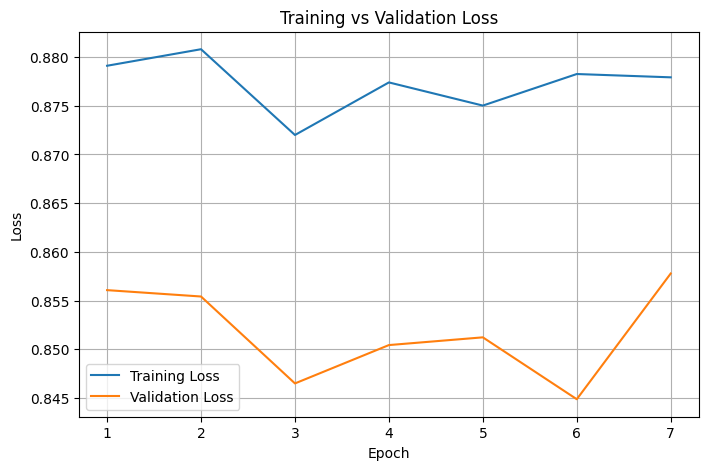

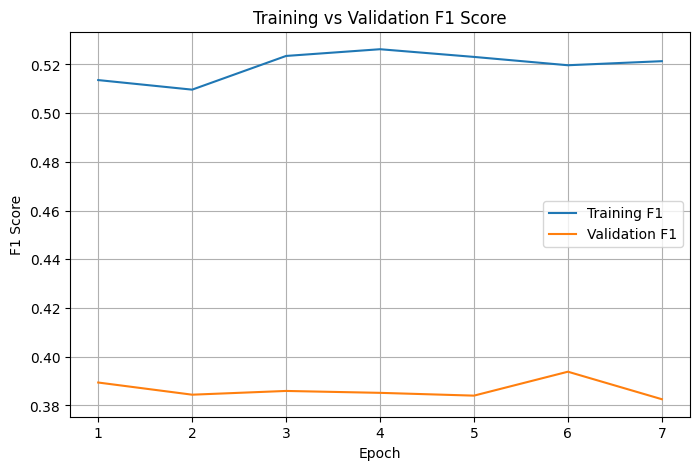

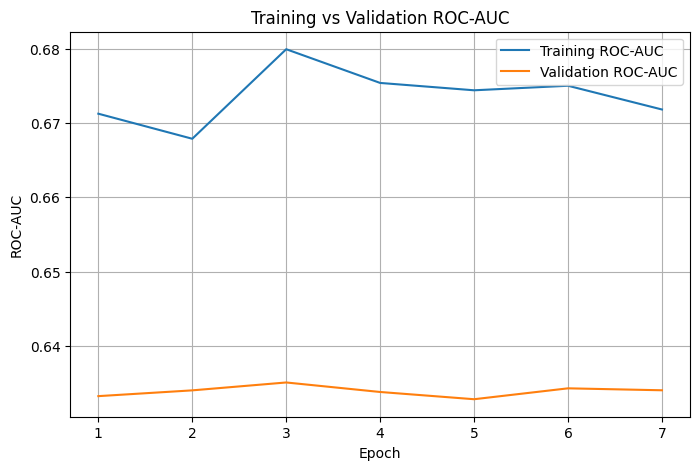

In [31]:
# ============================================================
# CELL 19 - TRAINING AND VALIDATION CURVES
# ============================================================

import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)


# ------------------------------------------------------------
# LOSS CURVE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# F1 SCORE CURVE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_f1"],
    label="Training F1"
)

plt.plot(
    epochs,
    history["val_f1"],
    label="Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("Training vs Validation F1 Score")
plt.legend()
plt.grid(True)

plt.show()


# ------------------------------------------------------------
# ROC-AUC CURVE
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_auc"],
    label="Training ROC-AUC"
)

plt.plot(
    epochs,
    history["val_auc"],
    label="Validation ROC-AUC"
)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("Training vs Validation ROC-AUC")
plt.legend()
plt.grid(True)

plt.show()

SPATIAL RECORDS
Training: 2549
Validation: 523
Test: 545
PatchDataset does not expose channel means/stds.
The spatial prediction will therefore use the SAME PatchDataset directly.

TRAINING SPATIAL PREDICTIONS


Predictions collected: 2549


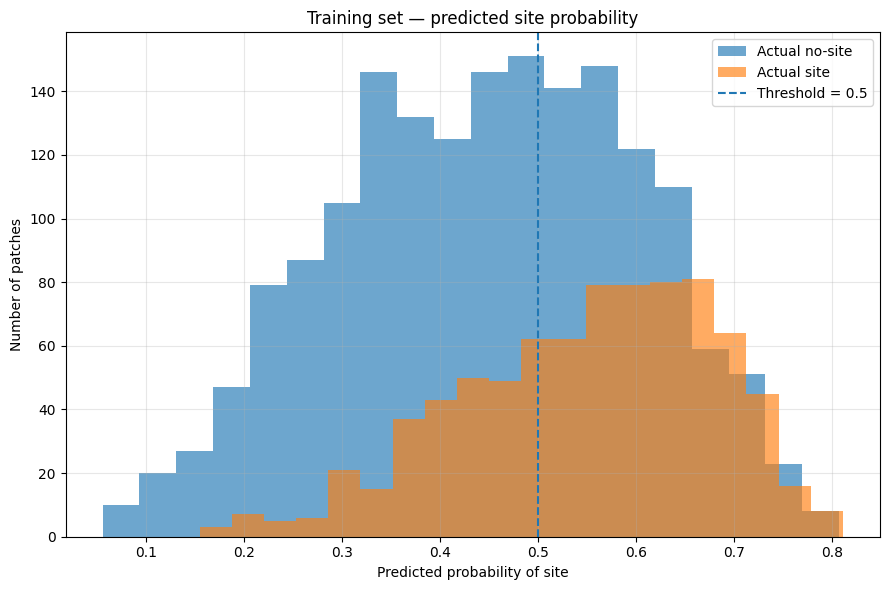

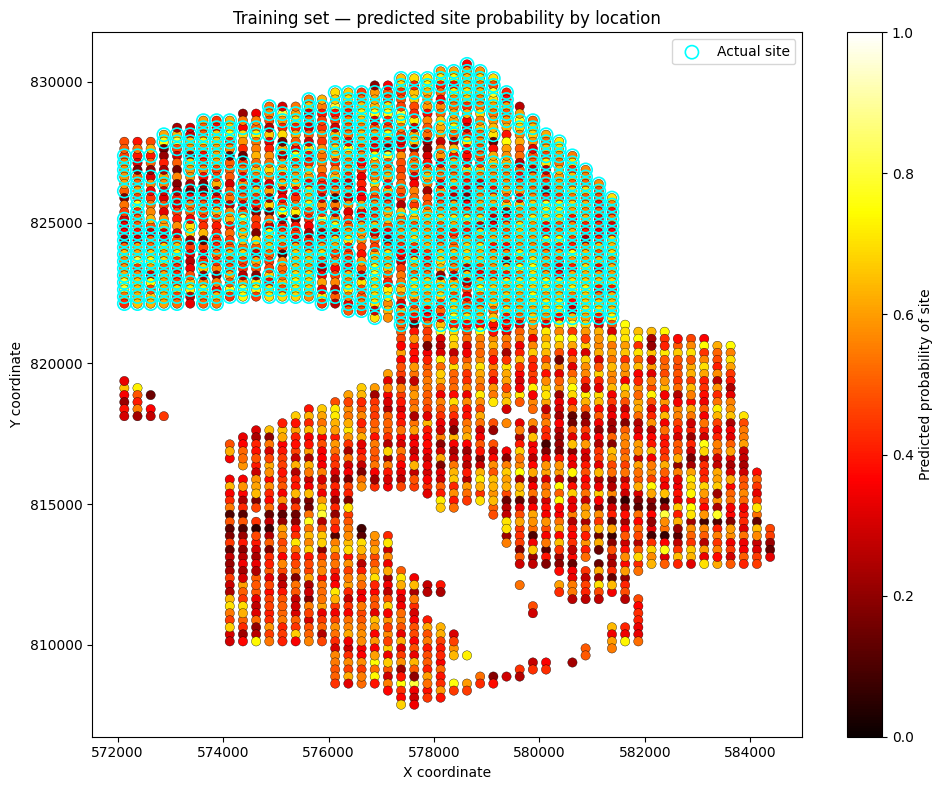


VALIDATION SPATIAL PREDICTIONS


Predictions collected: 523


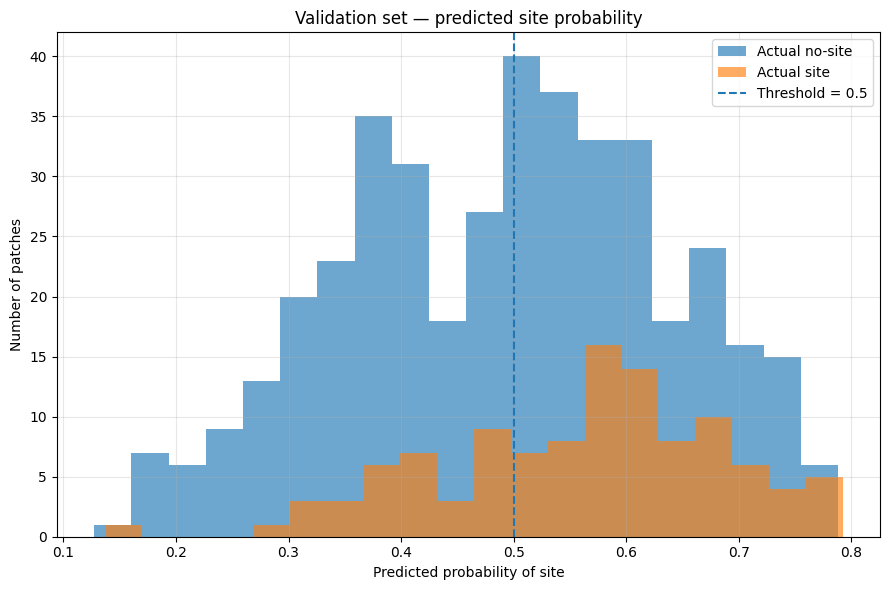

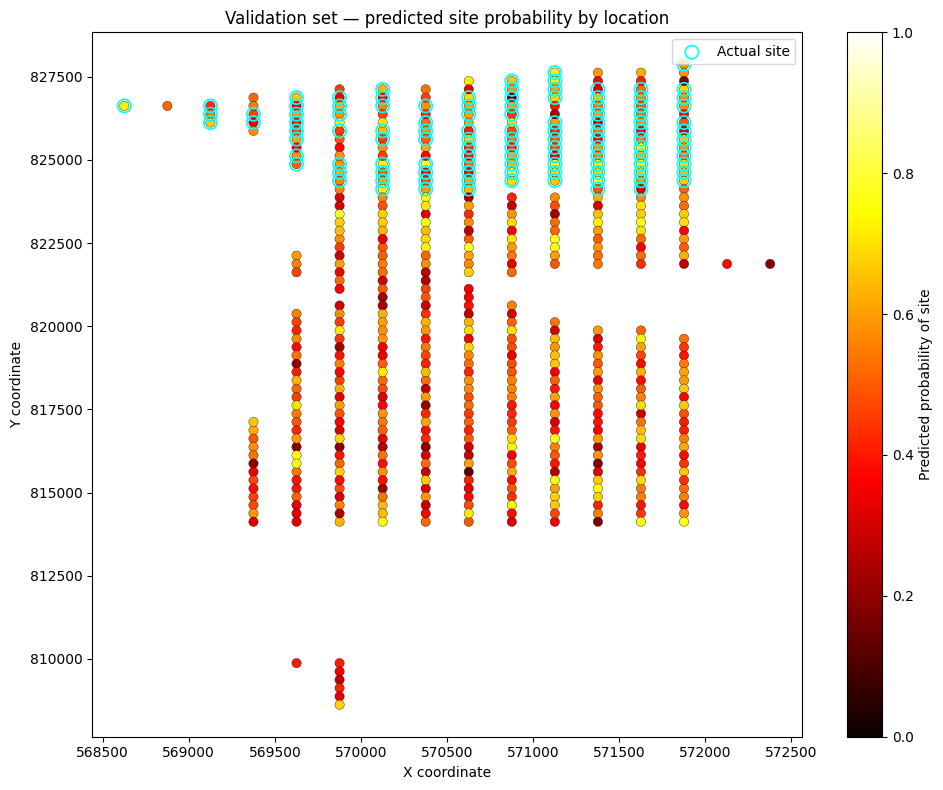


TEST SPATIAL PREDICTIONS


Predictions collected: 545


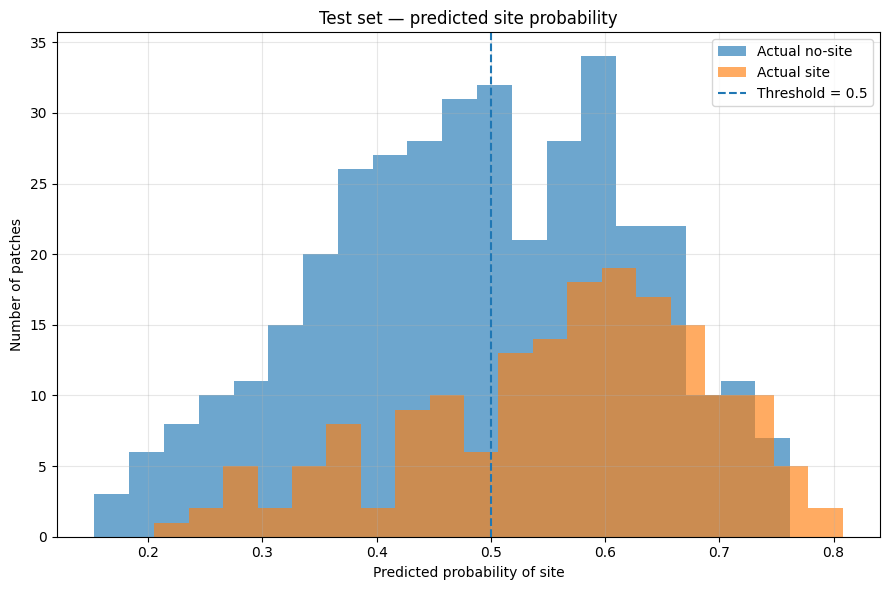

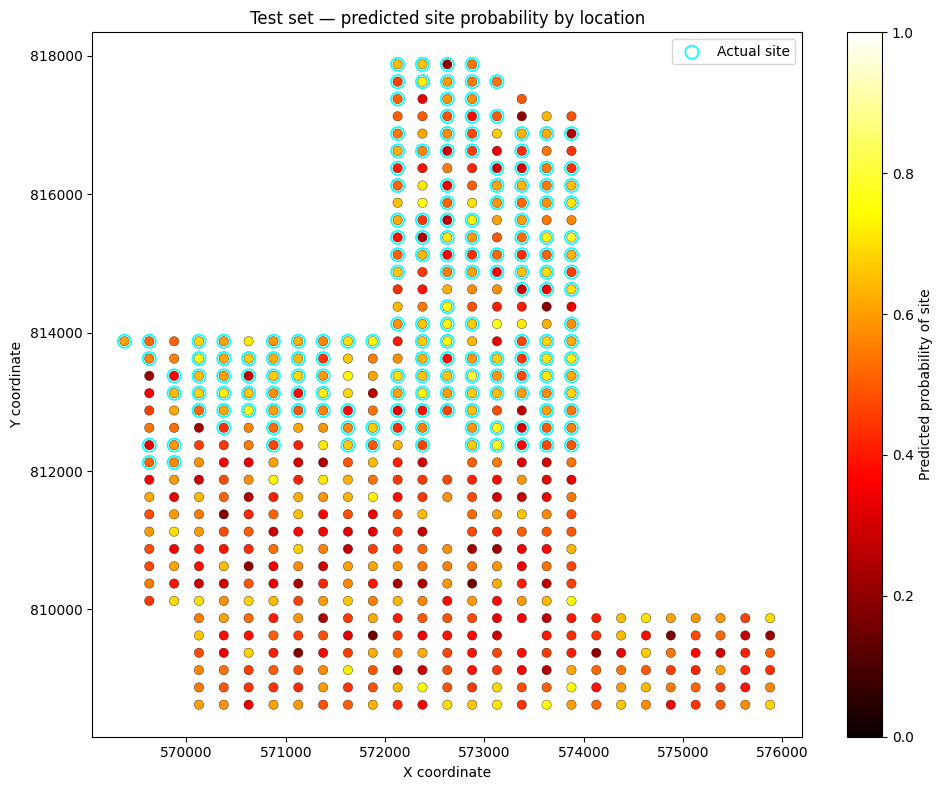


ALL HISTOGRAMS AND SPATIAL HEATMAPS GENERATED


In [32]:
# ============================================================
# CELL 20 - HISTOGRAM + SPATIAL HEATMAPS
# ============================================================

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import torch
from tqdm.auto import tqdm


# ============================================================
# 1. DATASET PATHS
# ============================================================

DATA_ROOT = (
    "/kaggle/input/datasets/beginne/"
    "datasetcnn/FINALCNNDATA_FINAL"
)

TRAIN_DIR = os.path.join(
    DATA_ROOT,
    "train"
)

VALIDATION_DIR = os.path.join(
    DATA_ROOT,
    "validation"
)

TEST_DIR = os.path.join(
    DATA_ROOT,
    "test"
)

# ============================================================
# 2. COLLECT FILES
# ============================================================

def collect_records(split_dir):

    records = []

    for class_name, label in [
        ("no_site", 0),
        ("site", 1)
    ]:

        class_dir = os.path.join(
            split_dir,
            class_name
        )

        tif_files = sorted(
            glob.glob(
                os.path.join(
                    class_dir,
                    "*.tif"
                )
            )
        )

        for file_path in tif_files:

            records.append(
                (
                    file_path,
                    label
                )
            )

    return records


train_records = collect_records(
    TRAIN_DIR
)

validation_records = collect_records(
    VALIDATION_DIR
)

test_records = collect_records(
    TEST_DIR
)


print("=" * 60)
print("SPATIAL RECORDS")
print("=" * 60)

print(
    "Training:",
    len(train_records)
)

print(
    "Validation:",
    len(validation_records)
)

print(
    "Test:",
    len(test_records)
)


# ============================================================
# 3. IMPORTANT:
#    USE THE SAME NORMALIZATION AS PatchDataset
# ============================================================

def get_dataset_normalization(dataset):

    possible_mean_names = [
        "channel_means",
        "channelMeans",
        "means",
        "mean",
        "mean_values"
    ]

    possible_std_names = [
        "channel_stds",
        "channelStds",
        "stds",
        "std",
        "std_values"
    ]

    means = None
    stds = None

    for name in possible_mean_names:

        if hasattr(dataset, name):

            means = getattr(
                dataset,
                name
            )

            break

    for name in possible_std_names:

        if hasattr(dataset, name):

            stds = getattr(
                dataset,
                name
            )

            break

    return means, stds


# Try the already-created training dataset

channel_means = None
channel_stds = None


if "train_dataset" in globals():

    channel_means, channel_stds = (
        get_dataset_normalization(
            train_dataset
        )
    )


# ============================================================
# 4. CHECK WHETHER PatchDataset STORES NORMALIZATION
# ============================================================

if channel_means is not None:

    channel_means = np.asarray(
        channel_means,
        dtype=np.float32
    )

    channel_stds = np.asarray(
        channel_stds,
        dtype=np.float32
    )

    print(
        "Found normalization values in train_dataset."
    )

    print(
        "Means:",
        channel_means
    )

    print(
        "Stds:",
        channel_stds
    )

else:

    print(
        "PatchDataset does not expose channel means/stds."
    )

    print(
        "The spatial prediction will therefore use "
        "the SAME PatchDataset directly."
    )


# ============================================================
# 5. SPATIAL PREDICTION FUNCTION
# ============================================================

def collect_spatial_predictions(
    model,
    dataset,
    records,
    device
):

    model.eval()

    xs = []
    ys = []
    probs = []
    true_labels = []

    with torch.no_grad():

        for index in tqdm(
            range(len(dataset)),
            desc="Collecting spatial predictions"
        ):

            try:

                # ------------------------------------------------
                # IMPORTANT:
                # Get the image exactly as PatchDataset prepares it
                # ------------------------------------------------

                image, label = dataset[index]

                # ------------------------------------------------
                # Find corresponding raster
                # ------------------------------------------------

                file_path = records[index][0]

                with rasterio.open(
                    file_path
                ) as raster:

                    bounds = raster.bounds


                # ------------------------------------------------
                # Patch centre
                # ------------------------------------------------

                center_x = (
                    bounds.left +
                    bounds.right
                ) / 2.0

                center_y = (
                    bounds.bottom +
                    bounds.top
                ) / 2.0


                # ------------------------------------------------
                # Make sure image is tensor
                # ------------------------------------------------

                if not torch.is_tensor(image):

                    image = torch.tensor(
                        image,
                        dtype=torch.float32
                    )

                image = (
                    image
                    .float()
                    .unsqueeze(0)
                    .to(device)
                )


                # ------------------------------------------------
                # Prediction
                # ------------------------------------------------

                output = model(
                    image
                )

                probability = torch.sigmoid(
                    output
                ).item()


                # ------------------------------------------------
                # Store
                # ------------------------------------------------

                xs.append(
                    center_x
                )

                ys.append(
                    center_y
                )

                probs.append(
                    probability
                )

                true_labels.append(
                    int(label)
                )


            except Exception as e:

                print(
                    f"\nSkipping record {index}"
                )

                print(
                    "File:",
                    records[index][0]
                )

                print(
                    "Error:",
                    e
                )


    return (
        np.asarray(xs),
        np.asarray(ys),
        np.asarray(probs),
        np.asarray(true_labels)
    )


# ============================================================
# 6. PROBABILITY HISTOGRAM
# ============================================================

def plot_probability_histogram(
    probabilities,
    true_labels,
    title,
    save_path
):

    probabilities = np.asarray(
        probabilities
    )

    true_labels = np.asarray(
        true_labels
    )


    plt.figure(
        figsize=(9, 6)
    )


    # Actual no-site patches

    plt.hist(
        probabilities[
            true_labels == 0
        ],
        bins=20,
        alpha=0.65,
        label="Actual no-site"
    )


    # Actual site patches

    plt.hist(
        probabilities[
            true_labels == 1
        ],
        bins=20,
        alpha=0.65,
        label="Actual site"
    )


    # Classification threshold

    plt.axvline(
        0.5,
        linestyle="--",
        linewidth=1.5,
        label="Threshold = 0.5"
    )


    plt.xlabel(
        "Predicted probability of site"
    )

    plt.ylabel(
        "Number of patches"
    )

    plt.title(
        title
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 7. SPATIAL HEATMAP
# ============================================================

def plot_spatial_heatmap(
    xs,
    ys,
    probs,
    true_labels,
    title,
    save_path
):

    plt.figure(
        figsize=(10, 8)
    )


    # Predicted probability

    scatter = plt.scatter(
        xs,
        ys,
        c=probs,
        cmap="hot",
        s=45,
        edgecolor="black",
        linewidth=0.25,
        vmin=0,
        vmax=1
    )


    # Actual archaeological sites

    site_mask = (
        true_labels == 1
    )


    plt.scatter(
        xs[site_mask],
        ys[site_mask],
        facecolors="none",
        edgecolors="cyan",
        linewidth=1.2,
        s=90,
        label="Actual site"
    )


    plt.colorbar(
        scatter,
        label="Predicted probability of site"
    )


    plt.xlabel(
        "X coordinate"
    )

    plt.ylabel(
        "Y coordinate"
    )

    plt.title(
        title
    )

    plt.legend(
        loc="upper right"
    )

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 8. TRAINING SET
# ============================================================

print(
    "\n" + "=" * 60
)

print(
    "TRAINING SPATIAL PREDICTIONS"
)

print(
    "=" * 60
)


train_xs, train_ys, train_probs, train_spatial_labels = (
    collect_spatial_predictions(
        model,
        train_dataset,
        train_records,
        DEVICE
    )
)


print(
    "Predictions collected:",
    len(train_probs)
)


plot_probability_histogram(
    train_probs,
    train_spatial_labels,
    "Training set — predicted site probability",
    "/kaggle/working/probability_histogram_train.png"
)


plot_spatial_heatmap(
    train_xs,
    train_ys,
    train_probs,
    train_spatial_labels,
    "Training set — predicted site probability by location",
    "/kaggle/working/spatial_heatmap_train.png"
)


# ============================================================
# 9. VALIDATION SET
# ============================================================

print(
    "\n" + "=" * 60
)

print(
    "VALIDATION SPATIAL PREDICTIONS"
)

print(
    "=" * 60
)


validation_xs, validation_ys, validation_probs, validation_spatial_labels = (
    collect_spatial_predictions(
        model,
        val_dataset,
        validation_records,
        DEVICE
    )
)


print(
    "Predictions collected:",
    len(validation_probs)
)


plot_probability_histogram(
    validation_probs,
    validation_spatial_labels,
    "Validation set — predicted site probability",
    "/kaggle/working/probability_histogram_validation.png"
)


plot_spatial_heatmap(
    validation_xs,
    validation_ys,
    validation_probs,
    validation_spatial_labels,
    "Validation set — predicted site probability by location",
    "/kaggle/working/spatial_heatmap_validation.png"
)


# ============================================================
# 10. TEST SET
# ============================================================

print(
    "\n" + "=" * 60
)

print(
    "TEST SPATIAL PREDICTIONS"
)

print(
    "=" * 60
)


test_xs, test_ys, test_probs_spatial, test_spatial_labels = (
    collect_spatial_predictions(
        model,
        test_dataset,
        test_records,
        DEVICE
    )
)


print(
    "Predictions collected:",
    len(test_probs_spatial)
)


plot_probability_histogram(
    test_probs_spatial,
    test_spatial_labels,
    "Test set — predicted site probability",
    "/kaggle/working/probability_histogram_test.png"
)


plot_spatial_heatmap(
    test_xs,
    test_ys,
    test_probs_spatial,
    test_spatial_labels,
    "Test set — predicted site probability by location",
    "/kaggle/working/spatial_heatmap_test.png"
)


# ============================================================
# 11. FINISHED
# ============================================================

print(
    "\n" + "=" * 60
)

print(
    "ALL HISTOGRAMS AND SPATIAL HEATMAPS GENERATED"
)

print(
    "=" * 60
)